<a href="https://colab.research.google.com/github/Husain-Asrarillah/Artificial-Intelligence-Praktikum-1/blob/main/Regresi_Logistik.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Library tambahan agar visualisasi logistik lebih cantik
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [3]:
# 1. Penyiapan Dataset (3 Variabel X)
# X1: Nilai Wawancara, X2: Nilai Tes Tulis, X3: Kehadiran Kegiatan (Skala 1-5)
# Y : Status Keputusan (0 = Ditolak, 1 = Diterima)
data = {
    'nilai_wawancara': [60, 75, 80, 50, 90, 85, 65, 70, 95, 55, 88, 78, 62, 92, 45],
    'nilai_tes_tulis': [65, 80, 75, 55, 85, 90, 60, 75, 95, 50, 80, 85, 55, 88, 40],
    'kehadiran_kegiatan': [3, 4, 5, 2, 5, 4, 3, 4, 5, 2, 5, 4, 3, 5, 1],
    'status_diterima': [0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0]
}
df = pd.DataFrame(data)

# Memisahkan 3 fitur (X) dan target (Y)
x = df[['nilai_wawancara', 'nilai_tes_tulis', 'kehadiran_kegiatan']]
y = df['status_diterima']

In [4]:
# 2. Pemisahan Data (Dibuat 80% Training, 20% Testing)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [8]:
# 3. Pelatihan Model Regresi Logistik
model = LogisticRegression()
model.fit(x_train, y_train)

print("--- PARAMETER MODEL LOGISTIK ---")
print("Intercept (Beta 0):", model.intercept_[0])
print("Koefisien (Beta 1, 2, 3):", model.coef_[0])
print("-" * 30)

--- PARAMETER MODEL LOGISTIK ---
Intercept (Beta 0): -71.27545143530237
Koefisien (Beta 1, 2, 3): [0.59589042 0.3629941  0.0233447 ]
------------------------------


In [6]:
# 4. Pengujian Model (Melihat prediksi kelas dan persentase peluangnya)
y_predic = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1] # Mengambil probabilitas kelas "1" (Diterima)

print("--- HASIL PREDIKSI DATA TESTING ---")
print("Status Asli (Y)      :", y_test.values)
print("Tebakan Model        :", y_predic)
print("Peluang Diterima (%) :", np.round(y_prob * 100, 1))

--- HASIL PREDIKSI DATA TESTING ---
Status Asli (Y)      : [0 1 0]
Tebakan Model        : [0 1 0]
Peluang Diterima (%) : [ 0.  99.8  0. ]


In [11]:
# 5. Evaluasi Error (Menggunakan Akurasi)
akurasi = metrics.accuracy_score(y_test, y_predic)
print(f"\nNilai Akurasi Model: {akurasi * 100}%")


Nilai Akurasi Model: 100.0%


In [12]:
# 6. Prediksi Calon Baru
# Misal ada kandidat: Wawancara 82, Tes 78, Kehadiran 4
data_baru = pd.DataFrame({'nilai_wawancara': [82], 'nilai_tes_tulis': [78], 'kehadiran_kegiatan': [4]})
prediksi_baru = model.predict(data_baru)
hasil_teks = "DITERIMA" if prediksi_baru[0] == 1 else "DITOLAK"
print(f"\n--- PREDIKSI KASUS BARU ---")
print(f"Prediksi untuk Kandidat Baru (82, 78, 4) adalah: {hasil_teks}")


--- PREDIKSI KASUS BARU ---
Prediksi untuk Kandidat Baru (82, 78, 4) adalah: DITERIMA


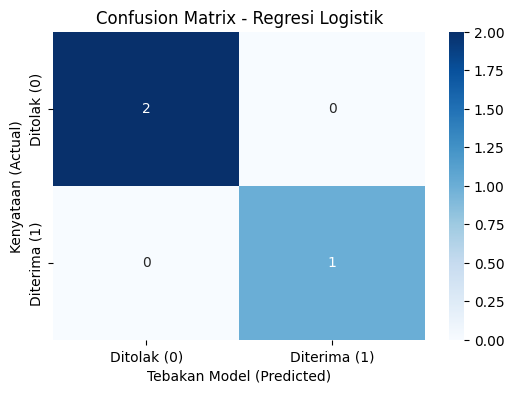

In [10]:
# 7. Visualisasi (Confusion Matrix)
cm = metrics.confusion_matrix(y_test, y_predic)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ditolak (0)', 'Diterima (1)'],
            yticklabels=['Ditolak (0)', 'Diterima (1)'])

plt.xlabel('Tebakan Model (Predicted)')
plt.ylabel('Kenyataan (Actual)')
plt.title('Confusion Matrix - Regresi Logistik')
plt.show()

**Analisis Praktikum: Regresi Logistik**

**1. Perubahan Karakteristik Model**

Pada tahap ini, saya mengubah pendekatan dari memprediksi nilai mutlak (seperti jumlah bug) menjadi memprediksi sebuah **probabilitas klasifikasi**. Saya menggunakan 3 variabel independen ($X$): **Nilai Wawancara**, **Nilai Tes Tulis**, dan **Tingkat Kehadiran**, untuk menentukan status penerimaan seorang kandidat ($Y$), di mana:
* **0** = Ditolak
* **1** = Diterima

Algoritma ini menggunakan **Fungsi Sigmoid** untuk memastikan hasil akhirnya selalu berada di antara 0 dan 1, yang kemudian dipetakan menjadi keputusan biner (Ya/Tidak).

**2. Evaluasi Metrik yang Berbeda**

Karena ini adalah masalah klasifikasi, saya tidak lagi menggunakan metrik regresi standar seperti **MAE** atau **RMSE**. Satuan *error* tersebut tidak relevan untuk data kategorik (pilihan kelompok). Sebagai gantinya, saya menggunakan metrik **Akurasi**. Jika nilai akurasinya **100%**, itu berarti model berhasil menebak semua data *testing* dengan benar tanpa ada yang tertukar antara kandidat yang lolos dan yang gagal.

**3. Penjelasan Visualisasi (Confusion Matrix)**

Untuk visualisasinya, saya tidak lagi menggunakan grafik garis atau *scatter plot*, melainkan **Confusion Matrix** (Matriks Kebingungan). Ini adalah standar terbaik untuk melihat performa klasifikasi:
* **Baris (Actual):** Mewakili kenyataan/data asli di lapangan.
* **Kolom (Predicted):** Mewakili tebakan atau prediksi dari model AI.
* **Diagonal Utama:** Angka pada kotak berwarna tebal yang membentang diagonal menunjukkan jumlah tebakan yang **benar**. Jika ada angka di luar garis diagonal tersebut, berarti model mengalami *error* atau salah klasifikasi.

**4. Kesimpulan Prediksi**

Model regresi logistik ini bekerja layaknya sistem pendukung keputusan HRD otomatis. Saat diuji dengan kandidat baru (Nilai Wawancara: **82**, Tes Tulis: **78**, Kehadiran: **Skala 4**), model secara otomatis menghitung probabilitasnya dan mengklasifikasikan kandidat tersebut ke dalam kategori **"DITERIMA"**.